# 1. Sandpile Model Definition

This section defines the basic BTW sandpile model. The model uses a finite 2D lattice. At each time step, sand is dropped onto one site randomly. If a site reaches the threshold, it topples and distributes grains to its four nearest neighbours.  

The avalanche observables used in this project are:

- **Topples**: total number of topplings in one avalanche
- **Area**: number of unique sites that toppled
- **Loss**: number of grains lost through the boundary
- **Length**: maximum radius from the initial dropped site to any toppled site

## 1.1 Core Functions

This section defines the core functions used to implement the BTW sandpile model. These functions describe the fundamental dynamics of the system, including sand addition, toppling rules, and avalanche propagation. Based on these rules, the model is able to simulate the evolution of the system and record the key avalanche properties used in later analysis. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class SandPile:
    """
    BTW sandpile model on a finite 2D grid.

    The class follows the structure suggested in sandpile.py:
    drop_sand(), mass(), topple(), and avalanche().
    """

    def __init__(self, width, height, threshold=4):
        """
        Initialize a sandpile with the specified width and height.
        """
        self.width = width
        self.height = height
        self.threshold = threshold

        self.grid = np.zeros((width, height), dtype=int)

        #Store total mass after each sand drop
        self.mass_history = []

        #Store avalanche statistics
        self.topples_history = []
        self.area_history = []
        self.loss_history = []
        self.length_history = []

        #Store current avalanche information
        self.current_topples = 0
        self.current_loss = 0
        self.current_toppled_sites = set()
        self.current_start_site = None

    def drop_sand(self, n=1, site=None):
        """
        Add n grains of sand to one site.

        If site is None, choose one random site and add all n grains there.
        This keeps the same definition used in our current project code.
        """
        if site is None:
            i = np.random.randint(0, self.width)
            j = np.random.randint(0, self.height)
        else:
            i, j = site

        self.grid[i, j] += n
        self.mass_history.append(self.mass())

        return (i, j)

    def mass(self):
        """
        Return the total mass of the sandpile.
        """
        return np.sum(self.grid)

    def topple(self, site):
        """
        Topple one unstable site.

        This method:
        - subtracts threshold grains from the site
        - gives 1 grain to each orthogonal neighbour
        - counts grains that leave the grid as boundary loss
        """
        i, j = site

        self.grid[i, j] -= self.threshold
        self.current_topples += 1
        self.current_toppled_sites.add((i, j))

        neighbours = [
            (i + 1, j),
            (i - 1, j),
            (i, j + 1),
            (i, j - 1)
        ]

        for ni, nj in neighbours:
            if 0 <= ni < self.width and 0 <= nj < self.height:
                self.grid[ni, nj] += 1
            else:
                self.current_loss += 1

    def avalanche(self, start):
        """
        Run the avalanche until all sites are stable.

        The four avalanche variables are defined as:
        - topples: total number of topplings
        - area: number of unique toppled sites
        - loss: number of grains lost through boundaries
        - length: avalanche radius, defined as the maximum Euclidean distance from start to toppled sites
        """
        self.current_topples = 0
        self.current_loss = 0
        self.current_toppled_sites = set()
        self.current_start_site = start

        unstable_sites = [start]

        while unstable_sites:
            site = unstable_sites.pop()
            i, j = site

            if self.grid[i, j] < self.threshold:
                continue

            self.topple(site)

            #The same site may still be unstable
            if self.grid[i, j] >= self.threshold:
                unstable_sites.append((i, j))

            #Check four neighbours after toppling
            neighbours = [
                (i + 1, j),
                (i - 1, j),
                (i, j + 1),
                (i, j - 1)
            ]

            for ni, nj in neighbours:
                if 0 <= ni < self.width and 0 <= nj < self.height:
                    if self.grid[ni, nj] >= self.threshold:
                        unstable_sites.append((ni, nj))

        topples = self.current_topples
        area = len(self.current_toppled_sites)
        loss = self.current_loss
        length = self.avalanche_length()

        self.topples_history.append(topples)
        self.area_history.append(area)
        self.loss_history.append(loss)
        self.length_history.append(length)

        return topples, area, loss, length

    def avalanche_length(self):
        """
        Compute avalanche length.
    
        Length is defined as the radius of the avalanche:
        the maximum Euclidean distance from the dropped site
        to any site that toppled during the avalanche.
        """
        if len(self.current_toppled_sites) == 0:
            return 0
    
        si, sj = self.current_start_site
    
        max_distance = 0
        for i, j in self.current_toppled_sites:
            distance = np.sqrt((i - si)**2 + (j - sj)**2)
            if distance > max_distance:
                max_distance = distance

        return max_distance

    def is_stable(self):
        """
        Check whether all sites are stable.
        """
        return np.all(self.grid < self.threshold)

    def reset_statistics(self):
        """
        Clear stored avalanche statistics.
        """
        self.topples_history = []
        self.area_history = []
        self.loss_history = []
        self.length_history = []

### 1.1.1 Quick model definition check

In [5]:
#Test 1
pile = SandPile(width=3, height=3)

pile.grid = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
])

print("Initial grid:")
print(pile.grid)

topples, area, loss, length = pile.avalanche(start=(1, 1))

print("\nFinal grid:")
print(pile.grid)

print("\nAvalanche statistics:")
print("Topples:", topples)
print("Area:", area)
print("Loss:", loss)
print("Length:", length)

print("\nStable:", pile.is_stable())

Initial grid:
[[0 0 0]
 [0 0 0]
 [0 0 0]]

Final grid:
[[0 0 0]
 [0 0 0]
 [0 0 0]]

Avalanche statistics:
Topples: 0
Area: 0
Loss: 0
Length: 0

Stable: True


In [6]:
#Test 2
pile = SandPile(width=3, height=3)

pile.grid = np.array([
    [0, 0, 0],
    [0, 4, 0],
    [0, 0, 0]
])

print("Initial grid:")
print(pile.grid)

topples, area, loss, length = pile.avalanche(start=(1, 1))

print("\nFinal grid:")
print(pile.grid)

print("\nAvalanche statistics:")
print("Topples:", topples)
print("Area:", area)
print("Loss:", loss)
print("Length:", length)

print("\nStable:", pile.is_stable())

Initial grid:
[[0 0 0]
 [0 4 0]
 [0 0 0]]

Final grid:
[[0 1 0]
 [1 0 1]
 [0 1 0]]

Avalanche statistics:
Topples: 1
Area: 1
Loss: 0
Length: 0

Stable: True


In [7]:
#Test 3
pile = SandPile(width=3, height=3)

pile.grid = np.array([
    [0, 3, 0],
    [0, 4, 0],
    [0, 0, 0]
])

print("Initial grid:")
print(pile.grid)

topples, area, loss, length = pile.avalanche(start=(1, 1))

print("\nFinal grid:")
print(pile.grid)

print("\nAvalanche statistics:")
print("Topples:", topples)
print("Area:", area)
print("Loss:", loss)
print("Length:", length)

print("\nStable:", pile.is_stable())

Initial grid:
[[0 3 0]
 [0 4 0]
 [0 0 0]]

Final grid:
[[1 0 1]
 [1 1 1]
 [0 1 0]]

Avalanche statistics:
Topples: 2
Area: 2
Loss: 1
Length: 1.0

Stable: True


In [8]:
#Test 4, correspond to the example in Chapter 2 of report
pile = SandPile(width=3, height=3)

pile.grid = np.array([
    [1, 3, 3],
    [2, 4, 2],
    [2, 1, 1]
])

print("Initial grid:")
print(pile.grid)

topples, area, loss, length = pile.avalanche(start=(1, 1))

print("\nFinal grid:")
print(pile.grid)

print("\nAvalanche statistics:")
print("Topples:", topples)
print("Area:", area)
print("Loss:", loss)
print("Length:", length)

print("\nStable:", pile.is_stable())

Initial grid:
[[1 3 3]
 [2 4 2]
 [2 1 1]]

Final grid:
[[2 1 1]
 [3 2 0]
 [2 2 2]]

Avalanche statistics:
Topples: 4
Area: 4
Loss: 4
Length: 1.4142135623730951

Stable: True


## 1.2 Simulation Wrapper

The `run_sandpile()` function is used to run the full simulation. It first performs a burn-in period so that the system can approach a statistically stationary state. After that, it records avalanche statistics for a fixed number of samples.

In [10]:
from tqdm import tqdm

def run_sandpile(N=50, burn_in=100000, samples=100000, seed=101):
    """
    Run the BTW sandpile simulation.

    N: The width and height of the square grid.
    burn_in: Number of sand drops before recording data. 
    samples: Number of sand drops used for recording avalanche statistics.
    seed: Random seed for reproducibility.

    results: Dictionary containing the final grid, mass history, and avalanche statistics.
    """

    np.random.seed(seed)

    pile = SandPile(width=N, height=N)

    for _ in tqdm(range(burn_in), desc="Burn-in"):
        site = pile.drop_sand(n=1)
        pile.avalanche(start=site)

    pile.reset_statistics()

    for _ in tqdm(range(samples), desc="Sampling"):
        site = pile.drop_sand(n=1)
        pile.avalanche(start=site)

    results = {
        "grid": pile.grid.copy(),
        "mass_history": np.array(pile.mass_history),
        "topples": np.array(pile.topples_history),
        "area": np.array(pile.area_history),
        "loss": np.array(pile.loss_history),
        "length": np.array(pile.length_history)
    }

    return results

### 1.2.1 Quick Simulation Test

In [12]:
#Test 1
results = run_sandpile(
    N=30,
    burn_in=5000,
    samples=10000,
    seed=101
)

print("Simulation finished.")
print("Final grid shape:", results["grid"].shape)
print("Number of recorded avalanches:", len(results["topples"]))
print("Final mass:", np.sum(results["grid"]))

print("\nFirst 10 topples:")
print(results["topples"][:10])

print("\nFirst 10 area:")
print(results["area"][:10])

print("\nFirst 10 loss:")
print(results["loss"][:10])

print("\nFirst 10 length:")
print(results["length"][:10])

Sampling: 100%|████████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 4219.69it/s]


Simulation finished.
Final grid shape: (30, 30)
Number of recorded avalanches: 10000
Final mass: 1887

First 10 topples:
[ 92   0 167   0   0   3   0   0   0   9]

First 10 area:
[ 92   0 139   0   0   3   0   0   0   9]

First 10 loss:
[0 0 4 0 0 1 0 0 0 0]

First 10 length:
[13.60147051  0.          9.05538514  0.          0.          1.41421356
  0.          0.          0.          2.82842712]


# Q4: Average Height and Steady State

Question 4 asks us to observe the average height of the sandpile after the system evolves from an empty lattice. The average height is computed as the total mass divided by the number of grid sites.

In [14]:
def plot_average_height(results, N, path=None):
    """
    Plot the average height of the sandpile over time.
    """
    mass_history = results["mass_history"]
    average_height = mass_history / (N * N)

    plt.figure(figsize=(7, 4))
    plt.plot(average_height)
    plt.xlabel("Time step")
    plt.ylabel("Average height")
    plt.title("Average Height Over Time")

    if path is not None:
        plt.savefig(path, bbox_inches="tight", dpi=300)

    plt.show()

    print("Final average height:", average_height[-1])

    return average_height

Burn-in: 100%|███████████████████████████████████████████████████████████████| 100000/100000 [01:24<00:00, 1182.77it/s]
Sampling: 0it [00:00, ?it/s]


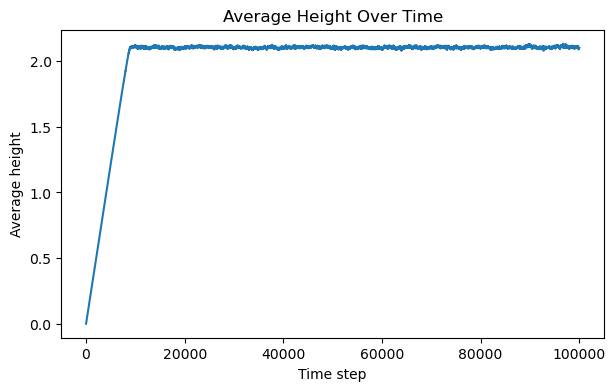

Final average height: 2.1005859375


In [15]:
#Q4 Simulation
N_q4 = 64
burn_in_q4 = 100000
samples_q4 = 0
seed_q4 = 101

q4_results = run_sandpile(
    N=N_q4,
    burn_in=burn_in_q4,
    samples=samples_q4,
    seed=seed_q4
)

q4_average_height = plot_average_height(
    q4_results,
    N=N_q4,
    path=None
)

# Q7: Distribution of Avalanche Properties

Question 7 asks us to record the frequency with which avalanches have a specific number of topples, area, loss, and length.  
It also asks what kind of distribution is observed for each variable, and whether a suitable fit can be found.  
For example, if the distribution is Gaussian, we should estimate the mean and width; if it follows a power law, we should estimate the exponent.

In this section, we first define the plotting and fitting functions, then apply them to the simulation results.

In [17]:
from scipy.stats import gamma

def plot_powerlaw_distribution(data, name, fit_range=None, path=None):
    #Remove zero values because log scale cannot include zero
    data = data[data > 0]

    #Count the frequency of each avalanche property
    max_value = int(data.max())
    counts = np.bincount(data, minlength=max_value + 1)

    x = np.arange(len(counts))
    y = counts / len(data)

    #Keep only valid positive points for log-log plotting
    mask = (x > 0) & (y > 0)

    #Select the fitting range
    if fit_range is not None:
        fit_mask = mask & (x >= fit_range[0]) & (x <= fit_range[1])
    else:
        fit_mask = mask

    #Fit a straight line in log-log space
    slope, intercept = np.polyfit(np.log(x[fit_mask]), np.log(y[fit_mask]), 1)
    exponent = -slope

    plt.figure(figsize=(5, 5))
    plt.loglog(x[mask], y[mask], "o", markersize=4, label="Simulation data")

    #Plot the fitted power-law line
    x_fit = x[fit_mask]
    y_fit = np.exp(intercept) * x_fit ** slope
    plt.loglog(x_fit, y_fit, "-", label=f"Fit: exponent = {exponent:.3f}")

    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.title(f"{name} distribution")
    plt.legend()

    if path is not None:
        plt.savefig(path, bbox_inches="tight", dpi=300)

    plt.show()

    print(f"{name} power-law exponent ≈ {exponent:.3f}")

    return exponent

def plot_gamma_distribution(data, name, bins=50, path=None):
    #Remove zero values before fitting
    data = data[data > 0]

    #Fit Gamma distribution using shape and scale parameters
    shape, loc, scale = gamma.fit(data, floc=0)

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=bins, density=True, alpha=0.6, edgecolor="black")

    #Plot fitted Gamma density
    x = np.linspace(data.min(), data.max(), 500)
    pdf = gamma.pdf(x, a=shape, loc=loc, scale=scale)

    plt.plot(
        x,
        pdf,
        linewidth=2,
        label=f"Gamma fit\nshape={shape:.3f}, scale={scale:.3f}"
    )

    plt.xlabel(name)
    plt.ylabel("Density")
    plt.title(f"{name} distribution with Gamma fit")
    plt.legend()

    if path is not None:
        plt.savefig(path, bbox_inches="tight", dpi=300)

    plt.show()

    print(f"{name} Gamma parameters:")
    print(f"shape = {shape:.3f}")
    print(f"scale = {scale:.3f}")

    return shape, scale

Sampling: 100%|██████████████████████████████████████████████████████████████| 200000/200000 [03:07<00:00, 1068.29it/s]


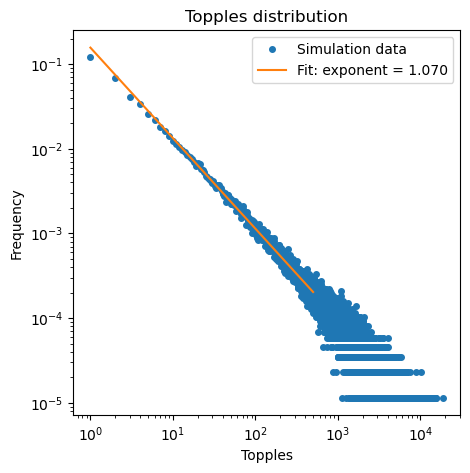

Topples power-law exponent ≈ 1.070


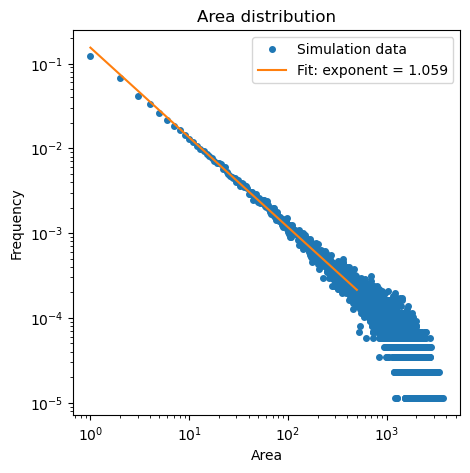

Area power-law exponent ≈ 1.059


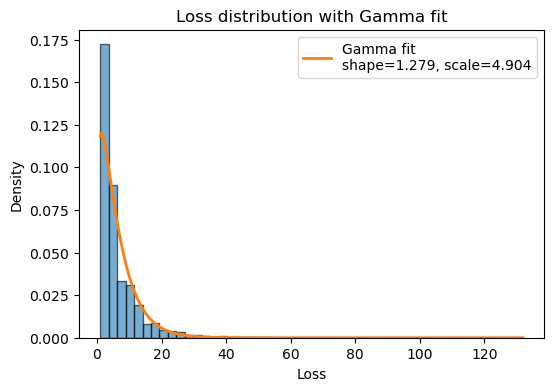

Loss Gamma parameters:
shape = 1.279
scale = 4.904


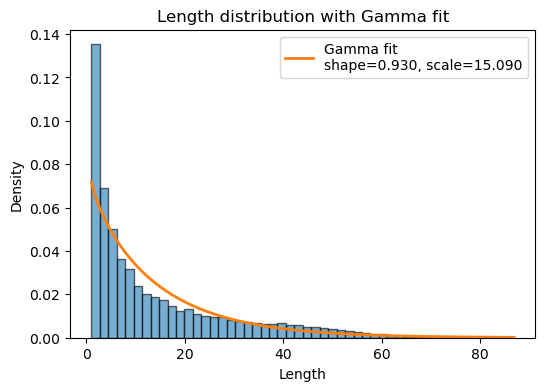

Length Gamma parameters:
shape = 0.930
scale = 15.090


In [18]:
#Q7 Simulation
results = run_sandpile(
    N=64,
    burn_in=100000,
    samples=200000,
    seed=101
)

#Power-law fit for Topples and Area
topples_exponent = plot_powerlaw_distribution(
    results["topples"],
    "Topples",
    fit_range=(1, 500),
    path=None
)

area_exponent = plot_powerlaw_distribution(
    results["area"],
    "Area",
    fit_range=(1, 500),
    path=None
)

#Gamma fit for Loss and Length
loss_gamma_shape, loss_gamma_scale = plot_gamma_distribution(
    results["loss"],
    "Loss",
    bins=50,
    path=None
)

length_gamma_shape, length_gamma_scale = plot_gamma_distribution(
    results["length"],
    "Length",
    bins=50,
    path=None
)

# Q8: Correlation Between Avalanche Properties

Question 8 asks whether we expect any correlation between the four recorded avalanche properties: topples, area, loss, and length.  
We are required to justify our expectations based on the model, and then verify these relationships using simulation results.

In [20]:
#The plots are shown on log-log scales because these variables can span several orders of magnitude.
def plot_correlation(results, path=None):
    """
    Plot all pairwise scatter plots between avalanche properties.

    Variables:
    - Topples
    - Area
    - Loss
    - Length
    """

    #Extract avalanche variables
    topples = results["topples"]
    area = results["area"]
    loss = results["loss"]
    length = results["length"]

    #All pairwise combinations
    pairs = [
        (topples, area, "Topples", "Area"),
        (topples, loss, "Topples", "Loss"),
        (topples, length, "Topples", "Length"),
        (area, loss, "Area", "Loss"),
        (area, length, "Area", "Length"),
        (length, loss, "Length", "Loss")
    ]

    correlation_results = {}

    for x, y, xlabel, ylabel in pairs:

        #Remove zero values for log-log plotting
        mask = (x > 0) & (y > 0)
        x_plot = x[mask]
        y_plot = y[mask]

        plt.figure(figsize=(5, 5))
        plt.scatter(x_plot, y_plot, s=8, alpha=0.4)

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(f"{xlabel} vs {ylabel}")

        #Use logarithmic axes
        plt.xscale("log")
        plt.yscale("log")

        #Save figure if a path is provided
        if path is not None:
            filename = f"{path}_{xlabel.lower()}_vs_{ylabel.lower()}.png"
            plt.savefig(filename, bbox_inches="tight", dpi=300)

        plt.show()

        #Compute Pearson correlation coefficient
        corr = np.corrcoef(x_plot, y_plot)[0, 1]
        correlation_results[f"{xlabel} vs {ylabel}"] = corr

        print(f"Correlation between {xlabel} and {ylabel}: {corr:.3f}")

    return correlation_results

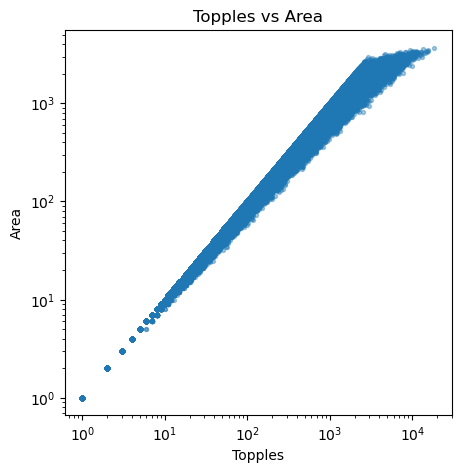

Correlation between Topples and Area: 0.926


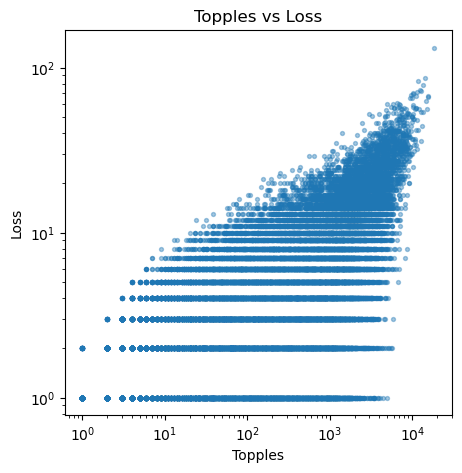

Correlation between Topples and Loss: 0.736


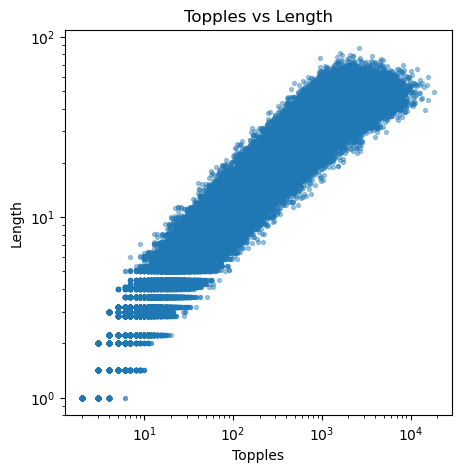

Correlation between Topples and Length: 0.733


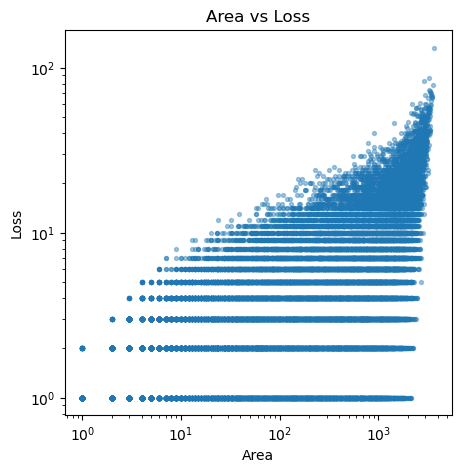

Correlation between Area and Loss: 0.684


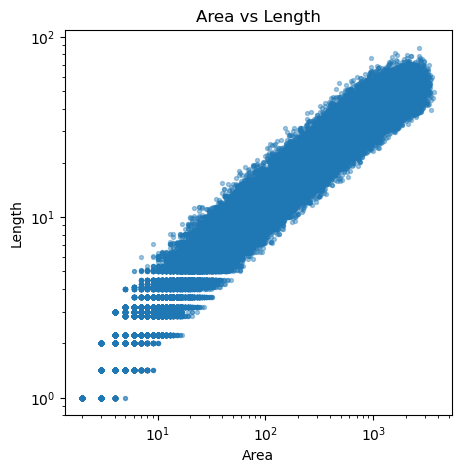

Correlation between Area and Length: 0.890


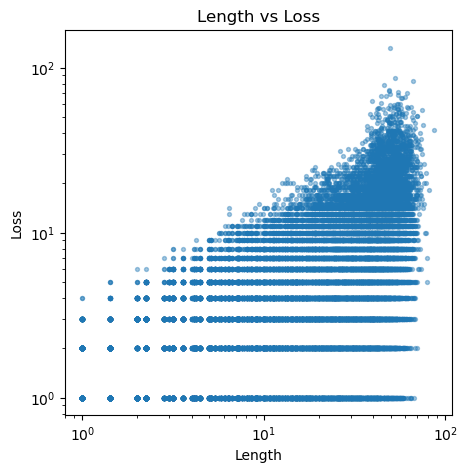

Correlation between Length and Loss: 0.547


{'Topples vs Area': 0.9260286118660717,
 'Topples vs Loss': 0.7355273006546412,
 'Topples vs Length': 0.7331964931467503,
 'Area vs Loss': 0.6844201760785663,
 'Area vs Length': 0.8895239532581016,
 'Length vs Loss': 0.5471202397830907}

In [21]:
correlations = plot_correlation(results, path=None)
correlations

# Extension

In [23]:
def run_sandpile_same_site_multi_drop(
    N=50,
    burn_in=100000,
    samples=100000,
    grains_per_step=3,
    seed=101
):
    """
    Run the BTW sandpile simulation with fast driving.

    Extension rule:
    At each time step, add multiple grains to the same random site,
    then relax the system once by running one avalanche.

    Parameters: 
    N: Width and height of the square grid.
    burn_in: Number of time steps before recording statistics.
    samples: Number of time steps used for recording statistics.
    grains_per_step: Number of grains added at each time step.
    seed: Random seed for reproducibility.
    """

    np.random.seed(seed)

    pile = SandPile(width=N, height=N)

    #Burn-in stage
    for _ in tqdm(range(burn_in), desc="Burn-in"):
        site = pile.drop_sand(n=grains_per_step)
        pile.avalanche(start=site)

    #Clear avalanche statistics before formal sampling
    pile.reset_statistics()

    #Sampling stage
    for _ in tqdm(range(samples), desc="Sampling"):
        site = pile.drop_sand(n=grains_per_step)
        pile.avalanche(start=site)

    results = {
        "grid": pile.grid.copy(),
        "mass_history": np.array(pile.mass_history),
        "topples": np.array(pile.topples_history),
        "area": np.array(pile.area_history),
        "loss": np.array(pile.loss_history),
        "length": np.array(pile.length_history)
    }

    return results

Burn-in: 100%|████████████████████████████████████████████████████████████████| 100000/100000 [04:29<00:00, 371.13it/s]
Sampling: 0it [00:00, ?it/s]


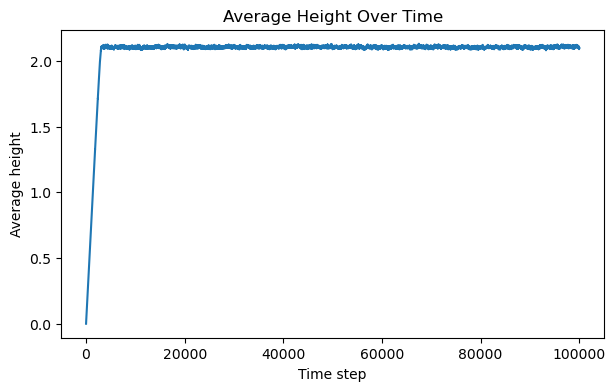

Final average height: 2.100341796875


In [24]:
q4_extension_results = run_sandpile_same_site_multi_drop(
    N=64,
    burn_in=100000,
    samples=0,
    grains_per_step=3,
    seed=101
)

q4_extension_average_height = plot_average_height(
    q4_extension_results,
    N=N_q4,
    path=None
)

In [25]:
extension_results = run_sandpile_same_site_multi_drop(
    N=64,
    burn_in=100000,
    samples=200000,
    grains_per_step=3,
    seed=101
)

Sampling: 100%|███████████████████████████████████████████████████████████████| 200000/200000 [08:51<00:00, 376.15it/s]


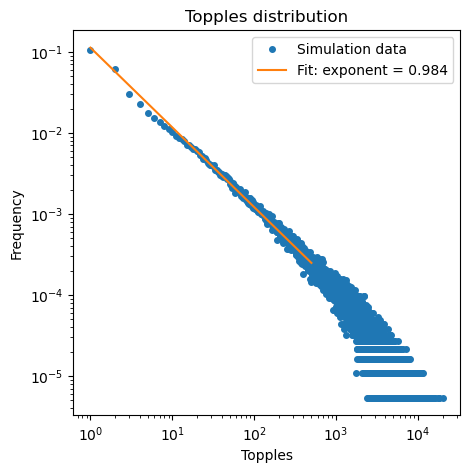

Topples power-law exponent ≈ 0.984


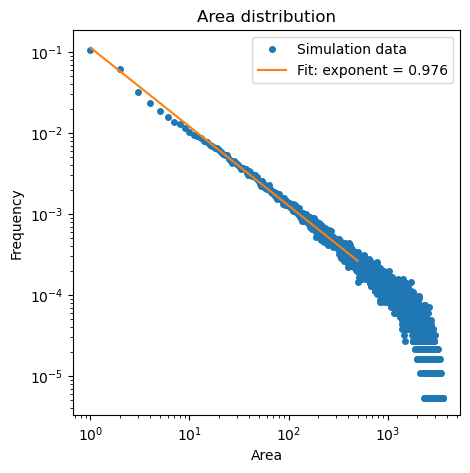

Area power-law exponent ≈ 0.976


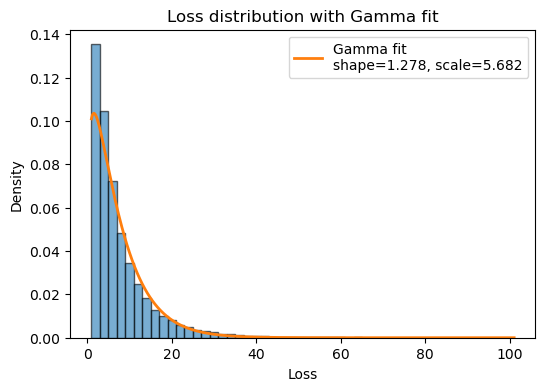

Loss Gamma parameters:
shape = 1.278
scale = 5.682


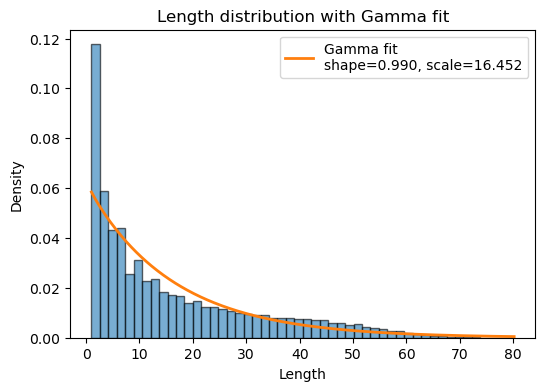

Length Gamma parameters:
shape = 0.990
scale = 16.452


(0.9903291440955332, 16.45187079211658)

In [26]:
plot_powerlaw_distribution(extension_results["topples"], "Topples", fit_range=(1, 500))
plot_powerlaw_distribution(extension_results["area"], "Area", fit_range=(1, 500))

plot_gamma_distribution(extension_results["loss"], "Loss", bins=50)
plot_gamma_distribution(extension_results["length"], "Length", bins=50)

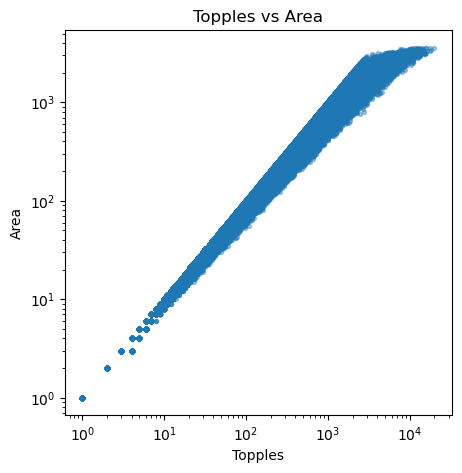

Correlation between Topples and Area: 0.921


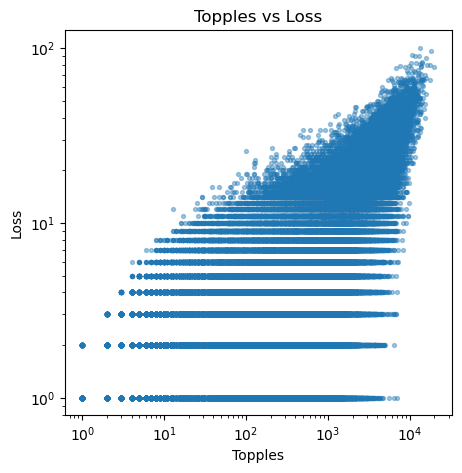

Correlation between Topples and Loss: 0.746


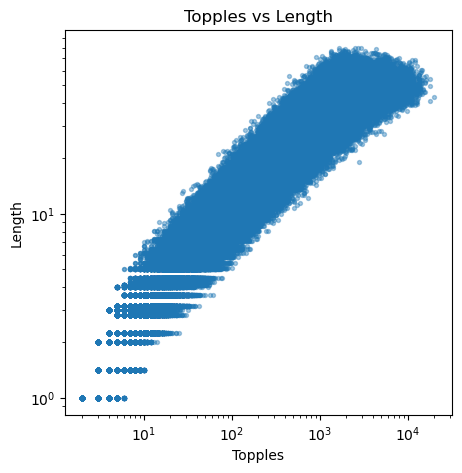

Correlation between Topples and Length: 0.724


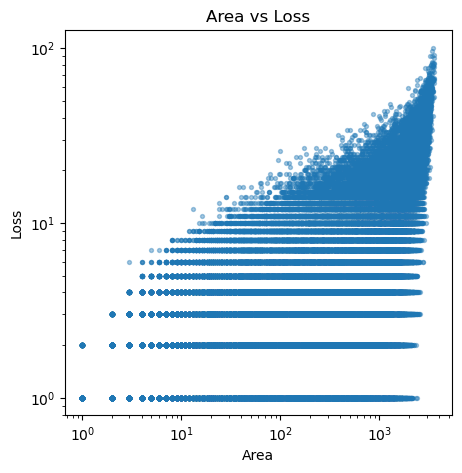

Correlation between Area and Loss: 0.692


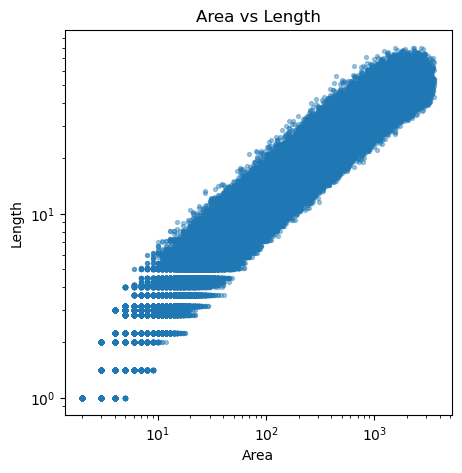

Correlation between Area and Length: 0.890


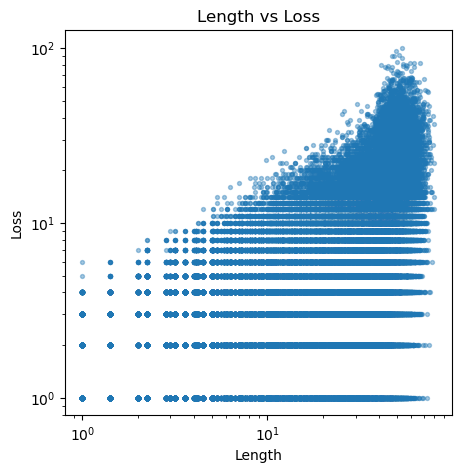

Correlation between Length and Loss: 0.549


{'Topples vs Area': 0.9208098670874212,
 'Topples vs Loss': 0.7459105133864573,
 'Topples vs Length': 0.7239819063039181,
 'Area vs Loss': 0.6921903635801351,
 'Area vs Length': 0.8896526422479827,
 'Length vs Loss': 0.5489199100328722}

In [27]:
extension_correlations = plot_correlation(extension_results, path=None)
extension_correlations